In [1]:
# from google.colab import drive
import os

# Mount Google Drive
# drive.mount('/content/drive')

In [2]:
import matplotlib.pyplot as plt
import os
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
import torchvision
from torchvision import transforms, models

In [3]:
import re

def sorted_alphanumeric(data):

    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    return sorted(data, key=alphanum_key)

In [4]:
class ImageDataset(Dataset):
    def __init__(self, low_path, high_path, size = 256):
        self.size = size
        self.low_path = low_path
        self.high_path = high_path
        self.high_files = sorted_alphanumeric(os.listdir(high_path))
        self.low_files = sorted_alphanumeric(os.listdir(low_path))

        # data argumentation
        self.train_transforms = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
        ])

    def __len__(self):
        return len(self.low_files)


    def __getitem__(self, idx):

        high_img_path = os.path.join(self.high_path, self.high_files[idx])
        low_img_path = os.path.join(self.low_path, self.low_files[idx])

        high_img = cv2.imread(high_img_path, 1)
        high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)
        high_img = cv2.resize(high_img, (self.size, self.size))
        high_img = high_img.astype('float32') / 255.0

        low_img = cv2.imread(low_img_path, 1)
        low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
        low_img = cv2.resize(low_img, (self.size//4, self.size//4))
        low_img = low_img.astype('float32') / 255.0

        return {
            'high_img': ToTensor()(high_img),
            'low_img': ToTensor()(low_img)
        }

In [5]:
high_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Train set\high_res'
low_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Train set\low_res'
test_high_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Test set\high_res'
test_low_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Test set\low_res'

# Create dataset instance
dataset = ImageDataset(low_res_path, high_res_path)
test_set = ImageDataset(test_low_res_path, test_high_res_path)

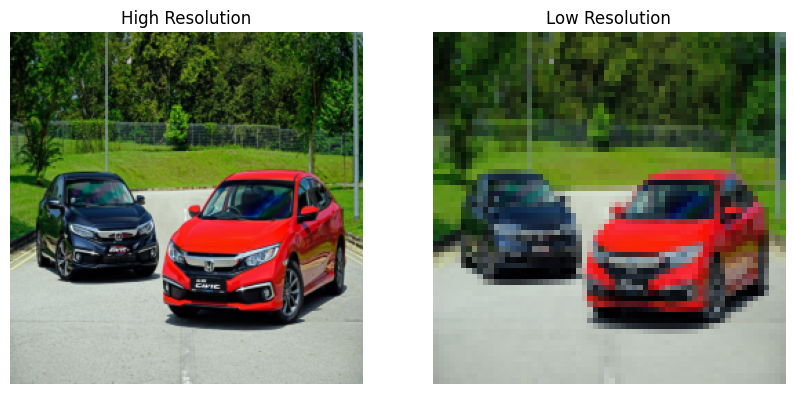

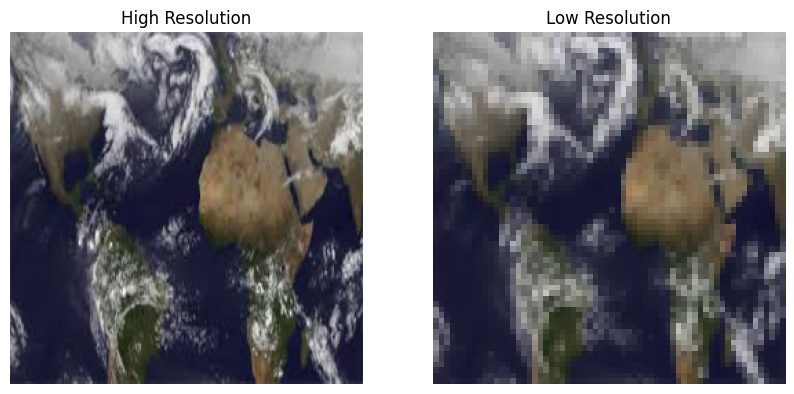

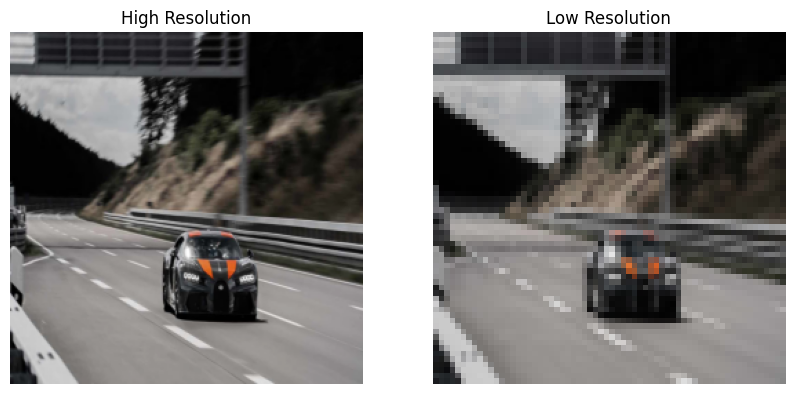

In [6]:
import matplotlib.pyplot as plt
import cv2
num_pairs_to_print = 3

for idx in range(num_pairs_to_print):
    sample = dataset[idx]
    high_img, low_img = sample['high_img'], sample['low_img']
    #Convert the pytorch tensors to numpy arrays
    #Matplotlib expects the images to be in the format : height, width, channels whereas the the pytroch tensor has it in the form of channels, height, width
    #After doing this we convert to the numpy array
    high_img_np = high_img.permute(1, 2, 0).numpy() if high_img.shape[0] == 3 else high_img.numpy()
    low_img_np = low_img.permute(1, 2, 0).numpy() if low_img.shape[0] == 3 else low_img.numpy()

    # Plot high-resolution and low-resolution images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(high_img_np)
    plt.title('High Resolution')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(low_img_np)
    plt.title('Low Resolution')
    plt.axis('off')

    plt.show()


In [7]:
from torch.utils.data import random_split

print("Number of high-resolution images:", len(dataset.high_files))
print("Number of low-resolution images:", len(dataset.low_files))
print("Number of Test high-resolution images:", len(test_set.high_files))
print("Number of Test low-resolution images:", len(test_set.low_files))

train_size = int(0.8 * len(dataset))
val_size = int(0.2 * len(dataset))
# Split the dataset into train, validation sets
train_set, val_set = random_split(dataset, [train_size, val_size])
print("Length of training set is: ", len(train_set))
print("Length of validation set is: ", len(val_set))
print("Length of testing set is: ", len(test_set))


Number of high-resolution images: 360
Number of low-resolution images: 360
Number of Test high-resolution images: 40
Number of Test low-resolution images: 40
Length of training set is:  288
Length of validation set is:  72
Length of testing set is:  40


In [8]:
batch_size = 5
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

MODEL

In [9]:
# using gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#build your model here
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        return x + residual

class SRResNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_residual_blocks=16):
        super(SRResNet, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=9, stride=1, padding=4)
        self.prelu = nn.PReLU()

        # Residual blocks
        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_residual_blocks)]
        )

        # Second conv layer after residual blocks
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        # Upsampling layers
        self.upsample1 = nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1)
        self.pixel_shuffle1 = nn.PixelShuffle(2)
        self.prelu1 = nn.PReLU()

        self.upsample2 = nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1)
        self.pixel_shuffle2 = nn.PixelShuffle(2)
        self.prelu2 = nn.PReLU()

        # Final output conv layer
        self.conv3 = nn.Conv2d(64, out_channels, kernel_size=9, stride=1, padding=4)

    def forward(self, x):
    # First conv + PReLU
        x = self.prelu(self.conv1(x))

        # Save the residual for skip connection
        residual = x

        # Residual blocks
        x = self.residual_blocks(x)

        # Second conv + BatchNorm (optional) + skip connection
        x = self.conv2(x)
        x = self.bn1(x)  # 使用 BatchNorm
        x = x + residual  # Skip connection

        # Upsampling + PixelShuffle + PReLU
        x = self.pixel_shuffle1(self.upsample1(x))
        x = self.prelu1(x)
        x = self.pixel_shuffle2(self.upsample2(x))
        x = self.prelu2(x)

        # Final conv to get the output image
        x = self.conv3(x)

        return x


#call model
model = SRResNet()

In [10]:
# Function to calculate PSNR (Peak Signal-to-Noise Ratio)
def calculate_psnr(img1, img2):
    mse = nn.functional.mse_loss(img1, img2)
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()

In [11]:
####################  implement your optimizer ###################################
## you can use any training methods if you want (ex:lr decay, weight decay.....)

model = model.to(device)

criterion = nn.MSELoss()  # 損失函數使用 MSELoss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_dacay=)  # 使用 Adam 優化器，學習率可以根據需求調整


# num_epochs : 可以先嘗試 10~15 次訓練
num_epochs = 300
psnr_best = 0.0

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)



for epoch in range(num_epochs):

    # Training phase
    model.train()
    running_loss = 0.0
    model.train()  # 設定模型為訓練模式
    running_loss = 0.0
    for data in train_loader:
        low_img, high_img = data['low_img'].to(device), data['high_img'].to(device)

        optimizer.zero_grad()  # 清空梯度
        outputs = model(low_img)  # 前向傳播
        loss = criterion(outputs, high_img)  # 計算損失
        loss.backward()  # 反向傳播
        optimizer.step()  # 更新權重

        running_loss += loss.item() * low_img.size(0)  # 累積損失

    # Validation phase
    model.eval()  # 設定模型為驗證模式
    val_loss = 0
    psnr_total = 0
    with torch.no_grad():  # 禁用梯度計算
        for data in val_loader:
            lr_imgs, hr_imgs = data['low_img'].to(device), data['high_img'].to(device)

            # Forward pass for validation
            outputs = model(lr_imgs)
            loss = criterion(outputs, hr_imgs)  # 計算驗證損失
            val_loss += loss.item() * lr_imgs.size(0)

            # Calculate PSNR for validation images
            psnr_total += calculate_psnr(outputs, hr_imgs)

    # 計算平均損失和 PSNR
    epoch_loss = running_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_psnr = psnr_total / len(val_loader)

    # scheduler.step()

    # Save the best model
    if avg_psnr >= psnr_best:
        psnr_best = avg_psnr
        print("model saved")
        torch.save(model, "model.pth")

    

    print(f'Epoch {epoch + 1}  Train Loss: {epoch_loss:.4f} | Val Loss: {avg_val_loss:.4f} | PSNR: {avg_psnr:.2f} dB')


model saved
Epoch 1  Train Loss: 0.0818 | Val Loss: 0.0933 | PSNR: 10.20 dB
model saved
Epoch 2  Train Loss: 0.0217 | Val Loss: 0.0419 | PSNR: 13.68 dB
model saved
Epoch 3  Train Loss: 0.0166 | Val Loss: 0.0175 | PSNR: 17.49 dB
model saved
Epoch 4  Train Loss: 0.0137 | Val Loss: 0.0164 | PSNR: 17.80 dB
model saved
Epoch 5  Train Loss: 0.0142 | Val Loss: 0.0096 | PSNR: 20.15 dB
model saved
Epoch 6  Train Loss: 0.0122 | Val Loss: 0.0085 | PSNR: 20.71 dB
Epoch 7  Train Loss: 0.0112 | Val Loss: 0.0087 | PSNR: 20.58 dB
model saved
Epoch 8  Train Loss: 0.0096 | Val Loss: 0.0074 | PSNR: 21.30 dB
model saved
Epoch 9  Train Loss: 0.0093 | Val Loss: 0.0072 | PSNR: 21.39 dB
Epoch 10  Train Loss: 0.0091 | Val Loss: 0.0085 | PSNR: 20.68 dB
Epoch 11  Train Loss: 0.0094 | Val Loss: 0.0082 | PSNR: 20.83 dB
model saved
Epoch 12  Train Loss: 0.0080 | Val Loss: 0.0072 | PSNR: 21.40 dB
Epoch 13  Train Loss: 0.0082 | Val Loss: 0.0075 | PSNR: 21.25 dB
model saved
Epoch 14  Train Loss: 0.0080 | Val Loss: 0.0

C:\Users\User\AppData\Local\Temp\ipykernel_7124\1591446467.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model = torch.load("model.pth").to(device)
Clipping input

PSNR for the testing data: 24.55 dB


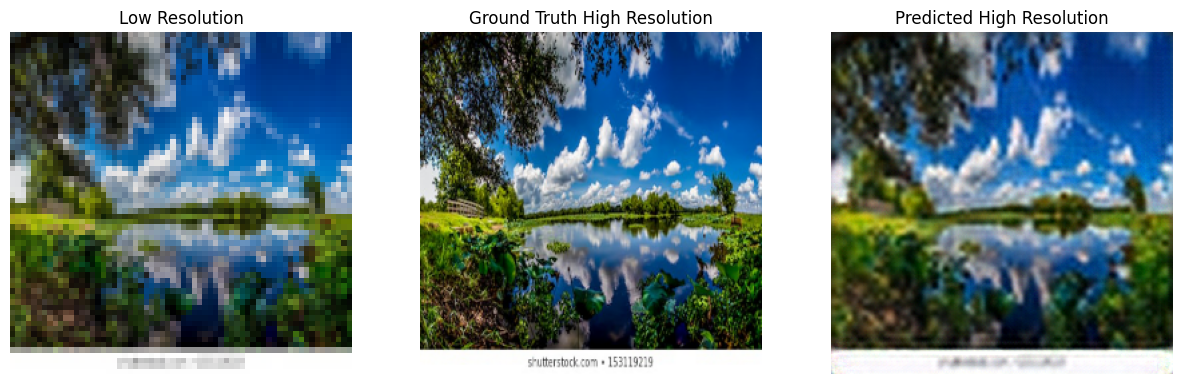

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.061540294..0.956001].


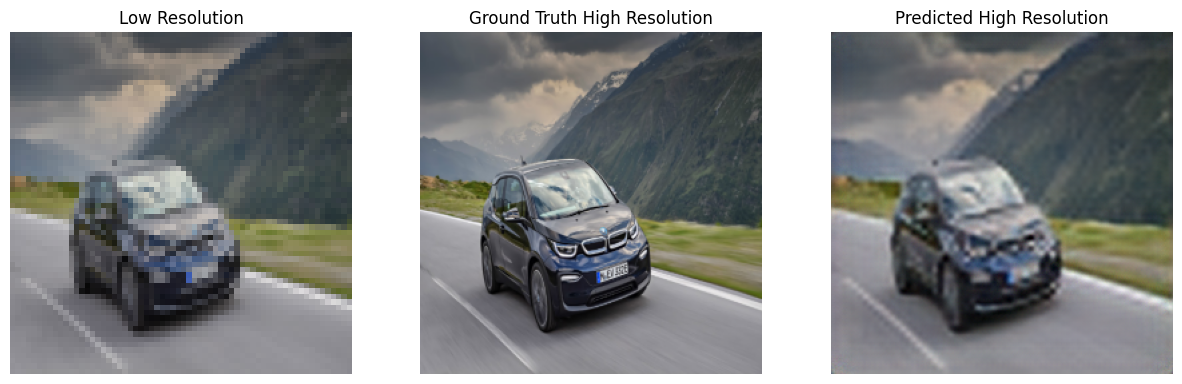

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.086453736..1.0721136].


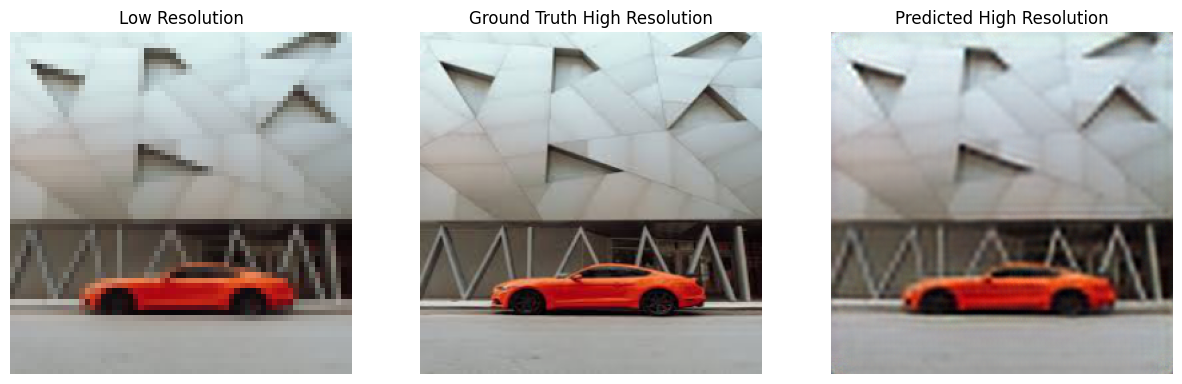

In [12]:
# load the model so that you don't need to train the model again
test_model = torch.load("model.pth").to(device)

# Set the model to evaluation mode
test_model.eval()
total_test_psnr = 0.0

# Run the model to get the reconstructed high-resolution images
with torch.no_grad():
  for test_batch in test_loader:
    # Move the low-res and high-res images to the same device as the model
    low_img = test_batch['low_img'].to(device)
    high_img = test_batch['high_img'].to(device)
    predicted_img = test_model(low_img)
    # Calculate PSNR for the current batch and accumulate the results
    psnr_value = calculate_psnr(predicted_img, high_img)
    total_test_psnr += psnr_value

test_psnr = total_test_psnr / len(test_loader)
print(f"PSNR for the testing data: {test_psnr:.2f} dB")

# Convert the tensors back to numpy arrays for visualization
high_img_np = high_img.cpu().permute(0, 2, 3, 1).numpy()  # (batch_size, height, width, channels)
low_img_np = low_img.cpu().permute(0, 2, 3, 1).numpy()    # (batch_size, height, width, channels)
predicted_img_np = predicted_img.cpu().permute(0, 2, 3, 1).numpy()  # (batch_size, height, width, channels)

# Plot some sample results
num_samples = 3  # Adjust this to show more/less samples
for i in range(num_samples):
    plt.figure(figsize=(15, 5))

    # Low resolution image
    plt.subplot(1, 3, 1)
    plt.imshow(low_img_np[i])
    plt.title('Low Resolution')
    plt.axis('off')

    # Ground truth high resolution image
    plt.subplot(1, 3, 2)
    plt.imshow(high_img_np[i])
    plt.title('Ground Truth High Resolution')
    plt.axis('off')

    # Predicted high resolution image
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_img_np[i])
    plt.title('Predicted High Resolution')
    plt.axis('off')

    plt.show()